# A one-year view of a small P&C insurer

This notebook uses `prospicio` end to end. It models three risks, each where it lives, then puts them together:

1. **Reserve risk**: an ODP bootstrap of the GenIns paid triangle.
2. **Fleet motor premium risk**: a Poisson GLM for claim frequency and a gamma GLM for severity on a policy file, into a collective model that carries the GLM's parameter uncertainty.
3. **Property per-risk**: a risk profile by sum-insured band, with a surplus treaty inuring to a per-risk excess of loss that has a paid reinstatement, pro rata as to time.

Then it prices the per-risk XL from its simulated losses, joins the three risks with a rank correlation, and sets and allocates capital at TVaR 99%, gross and net of reinsurance.

To run it, build the package (`cd python && maturin develop`), then open this notebook from anywhere in the repository. Set `PROSPICIO_EXAMPLE_SIMS` to run fewer simulations.

In [1]:
import csv
import math
import os
from pathlib import Path

from prospicio.aggregate import simulate_events
from prospicio.distributions import Gamma, PredictiveDistribution, claim_count
from prospicio.models import Glm, Terms
from prospicio.pricing import Mbbefd, RiskProfile, price
from prospicio.reinsurance import Layer, Tower
from prospicio.reserving import OdpBootstrap, Triangle
from prospicio.risk import Distortion, capital, iman_conover

N_SIMS = int(os.environ.get("PROSPICIO_EXAMPLE_SIMS", "20000"))
# The repository's data folder, from wherever the notebook runs.
DATA = next(p / "validation" / "data" for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "validation" / "data").is_dir())


def read_csv(name):
    with open(DATA / name) as f:
        return list(csv.DictReader(line for line in f if not line.startswith("#")))


def one_component(label, sampled):
    """A one-line PredictiveDistribution from a component's draws."""
    return PredictiveDistribution(["line"], [(label,)], [[x] for x in sampled.draws])


def money(x):
    return f"{x / 1e6:,.2f}m"

## 1. Reserve risk

GenIns is a cumulative paid triangle, ten origin years by ten ages. The ODP bootstrap resamples its scaled Pearson residuals and adds process noise. The result is a **joint** distribution of the reserve by origin, so the total keeps the dependence between origins.

In [2]:
rows = read_csv("genins.csv")
tri = Triangle.from_frame(
    {"origin": [int(r["origin"]) for r in rows],
     "age": [int(r["development"]) for r in rows],
     "paid": [float(r["value"]) for r in rows]},
    "origin", "age", "paid",
)
boot = OdpBootstrap(n_sims=N_SIMS, seed=1).fit(tri, "paid")
reserve = boot.reserves.total()
print(f"mean reserve {money(reserve.mean())}, 99.5% {money(reserve.quantile(0.995))}")

mean reserve 18.85m, 99.5% 28.09m


## 2. Fleet motor premium risk

The policy file has 600 fleet policies with age, region, exposure and claims; its amounts are in hundreds. Frequency is a Poisson GLM with log exposure as the offset. Severity is a gamma GLM on each policy's average claim, weighted by its number of claims, so its dispersion is a single claim's squared CV.

In [3]:
policies = read_csv("glm_policies.csv")
data = {"age": [float(p["age"]) for p in policies],
        "region": [p["region"] for p in policies]}
exposure = [float(p["exposure"]) for p in policies]
claims = [float(p["claims"]) for p in policies]

coding = Terms().intercept().numeric("age").factor("region").fit(data)
frequency = Glm("poisson").fit(coding.design(data, offset=[math.log(e) for e in exposure]), claims)
for name, b, se in zip(frequency.names, frequency.coefficients, frequency.std_errors):
    print(f"{name:12s} {b:8.4f}  (se {se:.4f})")

avg = [100.0 * float(p["avg_sev"]) for p in policies]
n_claims = [float(p["n_sev"]) for p in policies]
severity_fit = Glm("gamma", link="log").fit(
    Terms().intercept().fit(data).design(data, weights=n_claims), avg)
severity = Gamma.from_mean_cv(math.exp(severity_fit.coefficients[0]),
                              math.sqrt(severity_fit.dispersion))
print(f"mean claim {severity.mean():,.0f}, CV {severity.std() / severity.mean():.2f}")

(Intercept)   -0.3636  (se 0.2394)
age           -0.0105  (se 0.0045)
region[B]      0.0778  (se 0.1921)
region[C]     -0.2581  (se 0.2490)
region[D]      0.2036  (se 0.2448)
mean claim 106,806, CV 0.81


Next year every policy renews for a full year. The GLM's predictive distribution of the book's claim count includes parameter uncertainty (coefficients drawn from their asymptotic normal) as well as Poisson noise. A negative binomial with the same mean and variance carries both into a collective model.

In [4]:
counts = frequency.predict_distribution(
    coding.design(data, offset=[0.0] * len(policies)), N_SIMS, 2).total()
count_model = claim_count(counts.mean(), counts.variance() / counts.mean())
motor = simulate_events(count_model, severity, N_SIMS, 3).totals().total()
print(f"claims {counts.mean():.0f}, Var/E {counts.variance() / counts.mean():.2f}")
print(f"mean loss {money(motor.mean())}, 99.5% {money(motor.quantile(0.995))}")

claims 264, Var/E 2.76
mean loss 28.19m, 99.5% 36.98m


## 3. Property per-risk

Three bands of sum insured, each with its bounds, an expected loss and its own MBBEFD exposure curve (Swiss Re c = 2, 3, 4). Within a band, risks are spread evenly between the bounds.

The reinsurance has two stages:

- a **surplus treaty** with a 2m retention line and 4 lines (8m capacity);
- inuring to it, a **per-risk XL** of 3m xs 1m with one paid reinstatement at 100%, pro rata as to time.

The XL's upfront premium is its exposure-rated cost over a 70% loss ratio. Simulated losses are dated uniformly over the year, so each reinstatement is charged for the part of the year left after the loss.

In [5]:
profile = RiskProfile(
    [0.5e6, 3e6, 15e6], [4000, 600, 60],
    [Mbbefd.swiss_re(2.0), Mbbefd.swiss_re(3.0), Mbbefd.swiss_re(4.0)],
    expected_losses=[2.5e6, 2.0e6, 1.5e6],
    lower=[0.1e6, 1e6, 5e6], upper=[1e6, 5e6, 25e6],
)
retention, lines = 2e6, 4.0
xl_limit, xl_attachment = 3e6, 1e6
xl_cost = profile.expected_layer_loss(xl_limit, xl_attachment, retention, lines)
xl = Layer("per_risk_xl", xl_limit, xl_attachment, premium=xl_cost / 0.7,
           reinstatement_rates=[1.0], pro_rata_time=True)
tower = Tower.inuring([[Layer.surplus("surplus", retention, lines)], [xl]])

events = profile.simulate(N_SIMS, 4).with_uniform_times()
result = tower.apply(events)
gross = result.marginal(("gross", "ground_up"))
net = result.marginal(("net", "retained"))
surplus_loss = result.marginal(("ceded", "surplus"))
xl_loss = result.marginal(("ceded", "per_risk_xl"))
reinstated = result.marginal(("reinstatement_premium", "per_risk_xl"))

print(f"gross mean {money(gross.mean())}")
print(f"surplus cedes {money(surplus_loss.mean())}  (exposure rating {money(profile.expected_surplus_loss(retention, lines))})")
print(f"per-risk XL   {money(xl_loss.mean())}  (exposure rating {money(xl_cost)})")
print(f"reinstatement premium {money(reinstated.mean())}")
print(f"net mean {money(net.mean())}, 99.5% {money(net.quantile(0.995))}")

gross mean 6.03m
surplus cedes 1.50m  (exposure rating 1.49m)
per-risk XL   0.46m  (exposure rating 0.45m)
reinstatement premium 0.05m
net mean 4.07m, 99.5% 14.26m


The simulated cessions agree with exposure rating, which checks the simulation. But the net 99.5% is high: the top band runs to 25m, past the surplus's 2m + 8m, so its largest risks keep most of a total loss. More lines cut the net tail:

In [6]:
for more in [4.0, 8.0, 12.0]:
    alt = Tower.inuring([[Layer.surplus("surplus", retention, more)], [xl]]).apply(events)
    print(f"{more:4.0f} lines: net 99.5% {money(alt.marginal(('net', 'retained')).quantile(0.995))}")

   4 lines: net 99.5% 14.26m
   8 lines: net 99.5% 8.15m
  12 lines: net 99.5% 7.70m


**Pricing the XL** from its simulated losses: assets at TVaR 99% and a 10% cost of capital on the capital above the premium. The reinstatement premium the reinsurer expects to collect comes off.

In [7]:
xl_price = price(xl_loss, Distortion.tvar(0.99), cost_of_capital=0.10)
print(f"risk-loaded premium {money(xl_price.premium)}, capital {money(xl_price.capital)}")
print(f"net of expected reinstatements {money(xl_price.premium - reinstated.mean())}")

risk-loaded premium 0.81m, capital 3.51m
net of expected reinstatements 0.76m


## 4. The company

The three lines are joined into one `PredictiveDistribution`. Each was simulated on its own, so Iman–Conover reorders the draws to a rank correlation: 0.4 between reserve and motor (shared claims inflation), 0.1 for property. TVaR 99% of the year's losses is then allocated by Euler (each line's CoTVaR), gross and net of the property reinsurance.

In [8]:
corr = [[1.0, 0.4, 0.1], [0.4, 1.0, 0.1], [0.1, 0.1, 1.0]]


def company(property_line):
    parts = PredictiveDistribution.join(
        [("reserve", one_component("reserve", reserve)),
         ("motor", one_component("motor", motor)),
         ("property", one_component("property", property_line))],
        "risk",
    ).aggregate(["risk"])
    return iman_conover(parts, corr, seed=5)


tvar = Distortion.tvar(0.99)
companies, allocations = {}, {}
for label, line in [("gross", gross), ("net", net)]:
    companies[label] = company(line)
    allocations[label] = capital(companies[label], tvar)

print(f"{'':10s}{'gross':>10s}{'net':>10s}")
for i, key in enumerate(companies["gross"].components()):
    print(f"{key[0]:10s}{money(allocations['gross'].allocated[i]):>10s}{money(allocations['net'].allocated[i]):>10s}")
print(f"{'total':10s}{money(allocations['gross'].total):>10s}{money(allocations['net'].total):>10s}")
print(f"{'diversif.':10s}{money(allocations['gross'].diversification_benefit()):>10s}"
      f"{money(allocations['net'].diversification_benefit()):>10s}")
saved = allocations["gross"].total - allocations["net"].total
print(f"reinsurance cuts the company's TVaR by {money(saved)}")

               gross       net
reserve       22.00m    25.47m
motor         31.60m    34.32m
property      25.05m     8.84m
total         78.66m    68.63m
diversif.     14.97m    11.86m
reinsurance cuts the company's TVaR by 10.03m


The charts below show the distribution of the company's total, gross and net, and each line's share of TVaR 99%.

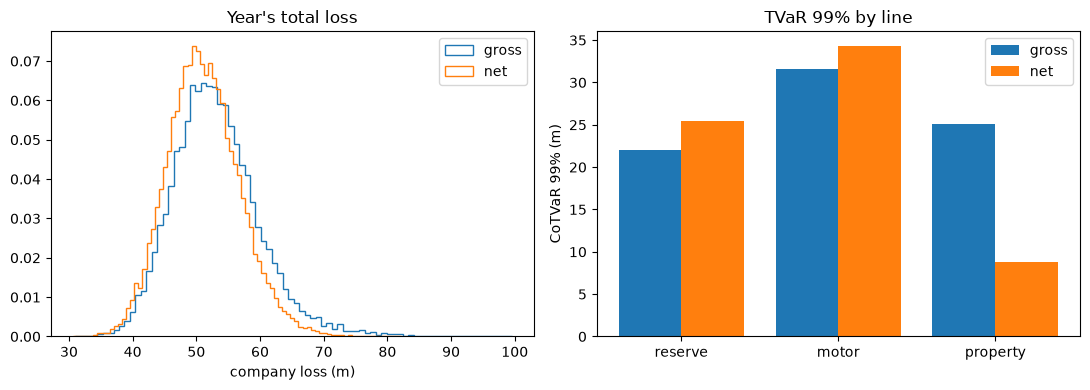

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for label in ["gross", "net"]:
    ax1.hist([x / 1e6 for x in companies[label].total().draws], bins=80,
             histtype="step", density=True, label=label)
ax1.set_xlabel("company loss (m)")
ax1.set_title("Year's total loss")
ax1.legend()

names = [k[0] for k in companies["gross"].components()]
x = range(len(names))
ax2.bar([i - 0.2 for i in x], [a / 1e6 for a in allocations["gross"].allocated], 0.4, label="gross")
ax2.bar([i + 0.2 for i in x], [a / 1e6 for a in allocations["net"].allocated], 0.4, label="net")
ax2.set_xticks(list(x), names)
ax2.set_ylabel("CoTVaR 99% (m)")
ax2.set_title("TVaR 99% by line")
ax2.legend()
plt.tight_layout()
plt.show()

## Reading the result

- Reserve and motor dominate the tail. They are larger and correlated with each other.
- Reinsurance cuts property's share of TVaR sharply. The company's TVaR falls by less than that, because property's tail was partly diversified already.
- Reserve and motor take *more* of the net TVaR than of the gross. Once property's extreme years are reinsured, the worst company years are the ones driven by reserve and motor.